In [1]:
# Import libraries needed for exploratory data analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Load the cleaned pricing dataset created in the previous notebook

DATA_PATH = Path("../data/processed/pricing_data.parquet")

df = pd.read_parquet(DATA_PATH)

print("Dataset shape:", df.shape)
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

display(df.head())

Dataset shape: (13774324, 20)
Memory usage: 446.66 MB


,date,item_id,dept_id,cat_id,store_id,state_id,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,demand
0,2011-01-29,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,0.46,12
1,2011-01-29,HOBBIES_1_028,HOBBIES_1,HOBBIES,CA_1,CA,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,6.67,0
2,2011-01-29,HOBBIES_1_029,HOBBIES_1,HOBBIES,CA_1,CA,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,7.44,2
3,2011-01-29,HOBBIES_1_032,HOBBIES_1,HOBBIES,CA_1,CA,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,0.47,9
4,2011-01-29,HOBBIES_1_036,HOBBIES_1,HOBBIES,CA_1,CA,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,0.96,2


In [3]:
# Summarize the main numerical variables used in pricing analysis

display(
    df[["sell_price", "demand"]]
    .describe()
)

,sell_price,demand
count,1.377432e+07,1.377432e+07
mean,3.683489e+00,2.364199e+00
std,2.652027e+00,6.194986e+00
min,1.000000e-02,0.000000e+00
25%,1.980000e+00,0.000000e+00
50%,2.970000e+00,1.000000e+00
75%,4.580000e+00,2.000000e+00
max,4.436000e+01,7.630000e+02


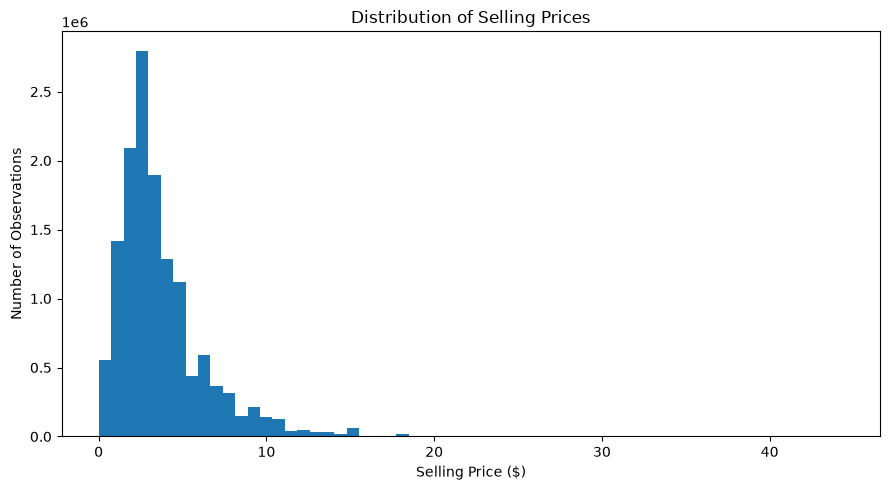

In [5]:
# Visualize the distribution of historical selling prices

plt.figure(figsize=(9, 5))

plt.hist(
    df["sell_price"],
    bins=60
)

plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price ($)")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

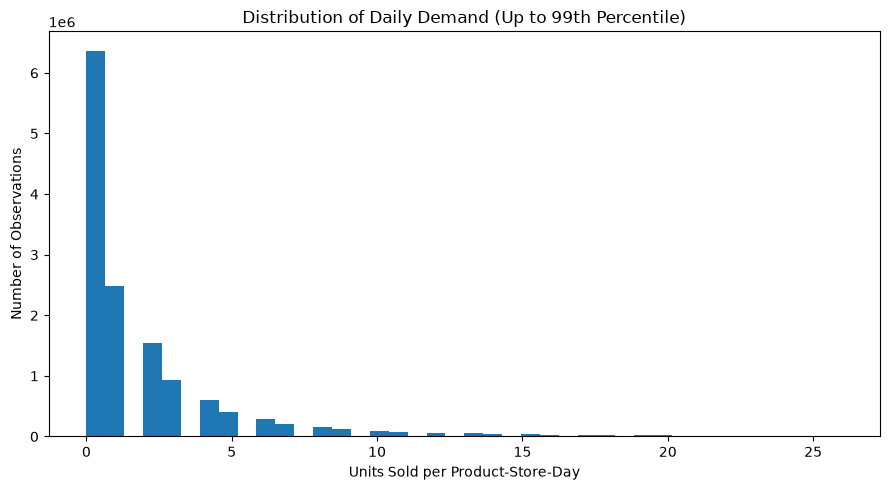

99th percentile demand: 26.0


In [6]:
# Visualize the typical demand distribution while limiting extreme values

demand_limit = df["demand"].quantile(0.99)

plt.figure(figsize=(9, 5))

plt.hist(
    df.loc[df["demand"] <= demand_limit, "demand"],
    bins=40
)

plt.title("Distribution of Daily Demand (Up to 99th Percentile)")
plt.xlabel("Units Sold per Product-Store-Day")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

print("99th percentile demand:", demand_limit)

cat_id
FOODS        2.719223
HOBBIES      1.733162
HOUSEHOLD    1.460488
Name: demand, dtype: float64

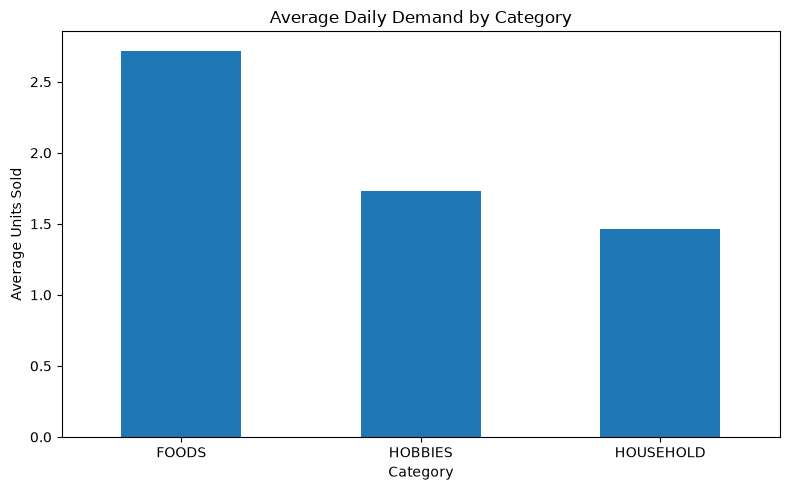

In [7]:
# Compare average daily demand across product categories

category_demand = (
    df.groupby("cat_id", observed=True)["demand"]
    .mean()
    .sort_values(ascending=False)
)

display(category_demand)

plt.figure(figsize=(8, 5))
category_demand.plot(kind="bar")

plt.title("Average Daily Demand by Category")
plt.xlabel("Category")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

,avg_price,avg_demand,observations
0,0.573503,4.756709,737856
1,1.059307,5.246619,739554
2,1.449739,7.049559,689909
3,1.746310,4.152563,624714
4,1.957247,2.431350,749725
5,2.132488,1.554642,744396
6,2.408099,2.209882,801041
7,2.500450,1.654524,425187
8,2.699831,1.744398,751018
9,2.912179,1.377772,758883


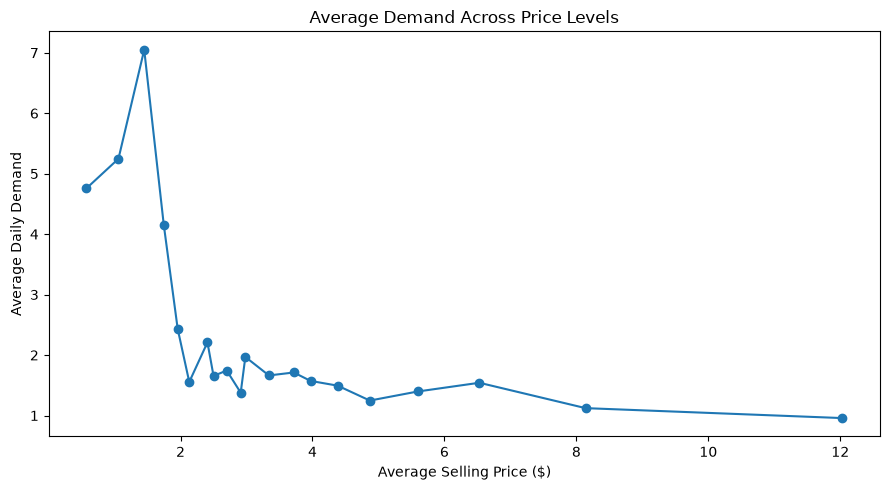

In [8]:
# Examine how average demand changes across historical price levels

price_analysis = df[["sell_price", "demand"]].copy()

price_analysis["price_bin"] = pd.qcut(
    price_analysis["sell_price"],
    q=20,
    duplicates="drop"
)

price_demand = (
    price_analysis.groupby("price_bin", observed=True)
    .agg(
        avg_price=("sell_price", "mean"),
        avg_demand=("demand", "mean"),
        observations=("demand", "size")
    )
    .reset_index(drop=True)
)

display(price_demand)

plt.figure(figsize=(9, 5))

plt.plot(
    price_demand["avg_price"],
    price_demand["avg_demand"],
    marker="o"
)

plt.title("Average Demand Across Price Levels")
plt.xlabel("Average Selling Price ($)")
plt.ylabel("Average Daily Demand")

plt.tight_layout()
plt.show()

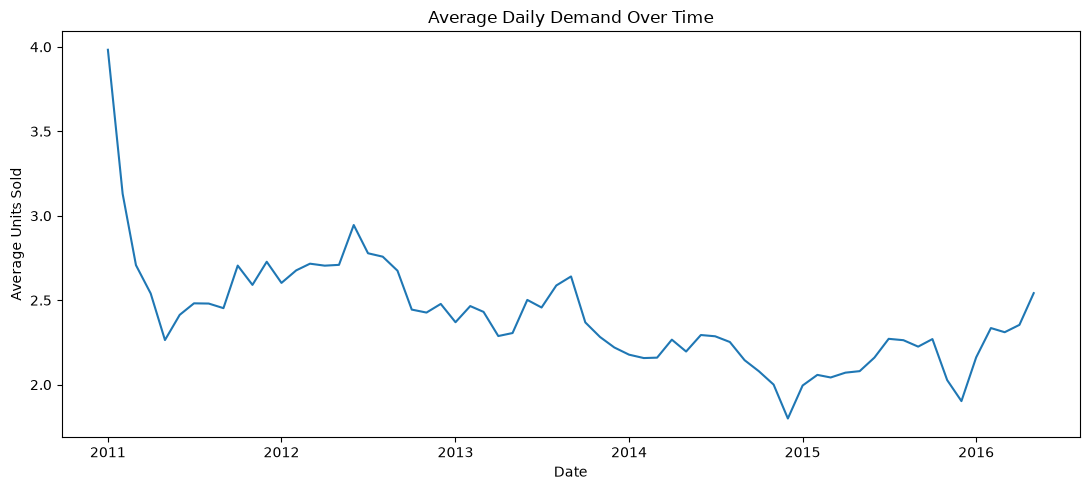

In [9]:
# Analyze the overall demand trend over time using monthly aggregation

monthly_demand = (
    df.groupby(df["date"].dt.to_period("M"))["demand"]
    .mean()
)

monthly_demand.index = monthly_demand.index.to_timestamp()

plt.figure(figsize=(11, 5))
plt.plot(monthly_demand.index, monthly_demand.values)

plt.title("Average Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Average Units Sold")

plt.tight_layout()
plt.show()

In [10]:
# Measure demand behavior on observations where a product's selling price changes

price_change_data = df[
    ["date", "item_id", "store_id", "sell_price", "demand"]
].sort_values(
    ["item_id", "store_id", "date"]
).copy()

price_change_data["previous_price"] = (
    price_change_data
    .groupby(["item_id", "store_id"], observed=True)["sell_price"]
    .shift(1)
)

price_change_data["price_change_pct"] = (
    (price_change_data["sell_price"] - price_change_data["previous_price"])
    / price_change_data["previous_price"]
) * 100

price_changes = price_change_data[
    price_change_data["price_change_pct"].notna() &
    (price_change_data["price_change_pct"] != 0)
].copy()

print("Price-change observations:", len(price_changes))

display(
    price_changes[
        [
            "date",
            "item_id",
            "store_id",
            "previous_price",
            "sell_price",
            "price_change_pct",
            "demand"
        ]
    ].head(10)
)

Price-change observations: 43114


,date,item_id,store_id,previous_price,sell_price,price_change_pct,demand
1556102,2011-10-22,FOODS_1_001,CA_3,2.00,1.75,-12.500000,0
1600063,2011-10-29,FOODS_1_001,CA_3,1.75,2.00,14.285715,0
3646594,2012-09-01,FOODS_1_001,CA_3,2.00,2.24,12.000000,0
6810544,2013-11-09,FOODS_1_001,CA_3,2.24,2.00,-10.714286,3
7438941,2014-02-01,FOODS_1_001,CA_3,2.00,2.24,12.000000,0
2177942,2012-01-28,FOODS_1_001,TX_1,2.00,1.19,-40.499996,0
2223426,2012-02-04,FOODS_1_001,TX_1,1.19,2.00,68.067215,0
2782403,2012-04-28,FOODS_1_001,TX_1,2.00,1.00,-50.000000,0
2829804,2012-05-05,FOODS_1_001,TX_1,1.00,2.00,100.000000,0
3648046,2012-09-01,FOODS_1_001,TX_1,2.00,2.24,12.000000,4


,wday,weekday,demand
0,1,Saturday,2.848251
1,2,Sunday,2.823090
2,3,Monday,2.269883
3,4,Tuesday,2.098459
4,5,Wednesday,2.068436
5,6,Thursday,2.087432
6,7,Friday,2.350229


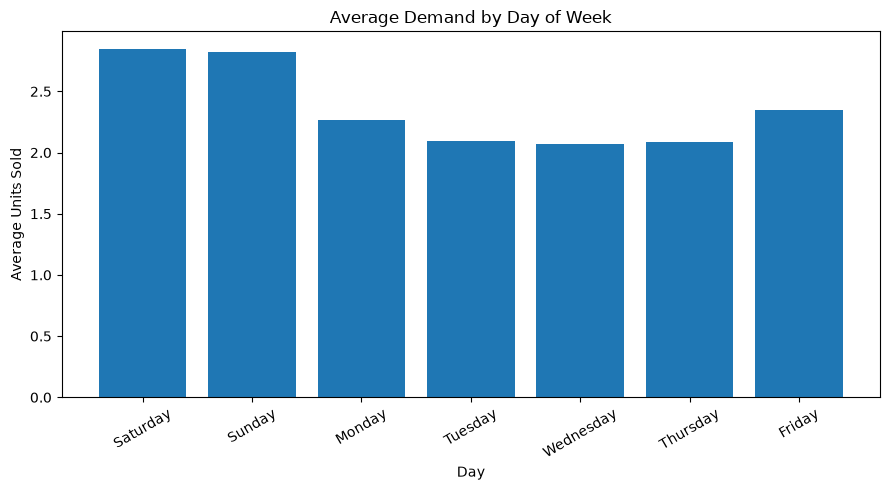

In [11]:
# Check whether demand systematically differs across days of the week

weekday_demand = (
    df.groupby(["wday", "weekday"], observed=True)["demand"]
    .mean()
    .reset_index()
    .sort_values("wday")
)

display(weekday_demand)

plt.figure(figsize=(9, 5))
plt.bar(weekday_demand["weekday"], weekday_demand["demand"])

plt.title("Average Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

,mean,median,count
day_type,,,
Event Day,2.295958,1.0,1119499
Normal Day,2.370236,1.0,12654825


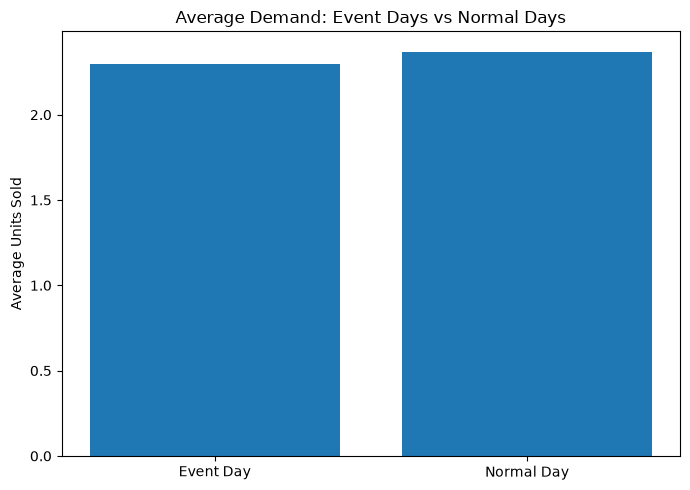

In [12]:
# Compare demand on calendar event days with demand on normal days

event_analysis = df[["event_name_1", "demand"]].copy()

event_analysis["day_type"] = np.where(
    event_analysis["event_name_1"].notna(),
    "Event Day",
    "Normal Day"
)

event_demand = (
    event_analysis.groupby("day_type")["demand"]
    .agg(["mean", "median", "count"])
)

display(event_demand)

plt.figure(figsize=(7, 5))
plt.bar(event_demand.index, event_demand["mean"])

plt.title("Average Demand: Event Days vs Normal Days")
plt.xlabel("")
plt.ylabel("Average Units Sold")

plt.tight_layout()
plt.show()

snap_active
0    2.267436
1    2.561192
Name: demand, dtype: float64

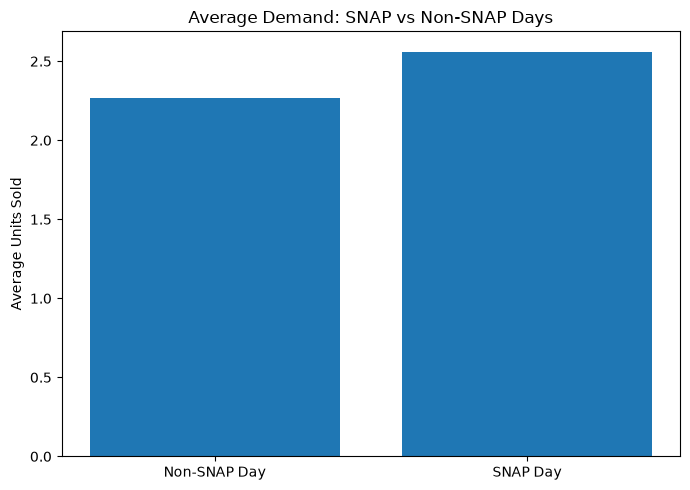

In [13]:
# Compare demand on SNAP and non-SNAP days using each store's state-specific indicator

df["snap_active"] = np.select(
    [
        df["state_id"] == "CA",
        df["state_id"] == "TX",
        df["state_id"] == "WI"
    ],
    [
        df["snap_CA"],
        df["snap_TX"],
        df["snap_WI"]
    ]
)

snap_demand = (
    df.groupby("snap_active")["demand"]
    .mean()
)

display(snap_demand)

plt.figure(figsize=(7, 5))
plt.bar(["Non-SNAP Day", "SNAP Day"], snap_demand.reindex([0, 1]))

plt.title("Average Demand: SNAP vs Non-SNAP Days")
plt.ylabel("Average Units Sold")

plt.tight_layout()
plt.show()

## EDA Summary

- Selling prices are right-skewed, with most observations concentrated at relatively low price levels.
- Daily demand is strongly right-skewed, with low unit sales being much more common than very high demand.
- Average demand differs substantially across product categories, with FOODS showing the highest average demand.
- Aggregate price-level analysis suggests a relationship between price and demand, but product-level analysis is required before interpreting this as price sensitivity.
- Demand changes over time, supporting the use of time-based features and time-aware model validation.
- 43,114 historical price-change observations were identified, providing useful variation for later price-elasticity analysis.
- Demand shows a clear weekly pattern, with Saturday and Sunday having the highest average demand.
- Overall event-day demand is similar to normal-day demand, so event effects should not be assumed to be uniformly positive.
- SNAP effects were examined to determine whether state-specific SNAP information should be retained for demand modeling.